# Assignment: Bike Sharing Demand Prediction with Deep Learning

## 머신러닝 과제 2 : 딥러닝 기반 자전거 대여 수요 예측

본 과제의 목표는 공개 데이터셋을 사용하여 **자전거 대여량을 예측하는 딥러닝 회귀 모델**을 구현하는 것입니다.

- 데이터셋: UCI Bike Sharing Dataset
- 사용 파일: `hour.csv`
- 목표 변수: `cnt`
- 문제 유형: Regression
- 평가 지표: RMSE, MAE, R² Score

이번 과제에선 데이터 이해, 전처리, 딥러닝 모델 구현, 성능 개선 및 하이퍼파라미터 튜닝 과정을 수행해야 합니다.

---

## 제출물

1. 완성된 Jupyter Notebook 파일
2. 실험 결과표
3. 최종 Test 성능 결과
4. 결과 해석 및 개선 과정 설명


## 0. Library Import

과제 수행에 필요한 라이브러리를 자유롭게 import하시오.

PyTorch 또는 TensorFlow/Keras 중 하나를 선택하여 딥러닝 모델을 구현할 수 있습니다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import random

# 재현성을 위한 시드 고정
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.12.0+cpu


# 1. Problem Understanding and Dataset Description

다음 내용을 포함하여 작성하시오.

- 본 과제가 해결하려는 문제 설명
- 데이터셋 출처 및 데이터셋에 대한 간단한 설명
- 입력 변수와 목표 변수 설명
- 사용할 성능 평가 지표 설명 (RMSE, MAE, R² Score)




### 1.1 Dataset Description

아래에 데이터셋에 대한 설명을 작성하시오.

**작성 공간**

- **문제 설명**: 본 과제는 시간대별 자전거 대여 수요 데이터를 활용하여, 특정 환경 조건(날씨, 시간, 요일 등)에 따른 총 대여량(`cnt`)을 예측하는 회귀(Regression) 문제를 딥러닝으로 해결하는 것을 목표로 합니다.
- **데이터셋**: UCI Machine Learning Repository의 Bike Sharing Dataset (`hour.csv`)을 사용합니다.
- **입력 변수**: `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed`.
- **목표 변수**: `cnt` (총 대여량)
- **평가 지표**:
    - **RMSE (Root Mean Squared Error)**: 예측 오차의 제곱 평균의 제곱근으로, 큰 오차에 더 큰 패널티를 부여합니다.
    - **MAE (Mean Absolute Error)**: 예측값과 실제값 차이의 절대값 평균으로, 직관적인 오차 규모를 보여줍니다.
    - **R² Score (Coefficient of Determination)**: 모델이 데이터를 얼마나 잘 설명하는지 나타내는 지표로, 1에 가까울수록 성능이 좋습니다.

# 2. Data Preprocessing

모델 학습에 적합하도록 데이터를 전처리하시오.

필수 포함 내용:

- 데이터 불러오기
- 데이터의 기본 정보 확인
- 결측치 확인
- 불필요한 변수 처리
- 범주형/수치형 변수 처리
- train/validation/test split
- feature scaling 또는 normalization

> 주의: target variable과 직접적으로 연결되어 데이터 누수를 일으킬 수 있는 변수는 입력 feature에서 제거해야 합니다.

In [ ]:
# 2.1 데이터 불러오기
df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
# 2.2 데이터 기본 정보 확인
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB
None

Missing Values:
 instant       0
dteday        0
season   

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
# 2.3 입력 변수와 목표 변수 분리
# [중요] 데이터 누수 방지
# casual, registered는 합이 cnt이므로 제거
# instant는 단순 인덱스, dteday는 날짜 문자열이므로 제거
drop_cols = ['instant', 'dteday', 'casual', 'registered']
X = df.drop(columns=drop_cols + ['cnt'])
y = df['cnt']

print("Used Features:", X.columns.tolist())

Used Features: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


In [ ]:
# 2.4 데이터 분리 및 스케일링
# Train:Val:Test = 60:20:20
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Feature Scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Target Scaling (회귀 문제에서 안정적인 학습을 위함)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# PyTorch TensorDataset 및 DataLoader 생성
def to_tensor(data):
    return torch.FloatTensor(data)

train_ds = TensorDataset(to_tensor(X_train_scaled), to_tensor(y_train_scaled))
val_ds = TensorDataset(to_tensor(X_val_scaled), to_tensor(y_val_scaled))
test_ds = TensorDataset(to_tensor(X_test_scaled), to_tensor(y_test_scaled))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 10427, Val size: 3476, Test size: 3476


### 2.6 Preprocessing Summary

수행한 전처리 과정을 간단히 설명하시오.

**작성 공간**

- **제거한 변수**: `instant`, `dteday`, `casual`, `registered`. (`casual`과 `registered`는 타겟값 `cnt`와 직접적인 산술 관계가 있어 데이터 누수를 방지하기 위해 반드시 제거해야 함)
- **범주형 변수 처리 방법**: 데이터셋 내 범주형 변수들이 이미 숫자로 인코딩되어 있어, 그대로 수치형 데이터와 함께 입력으로 사용함.
- **수치형 변수 처리 방법**: `StandardScaler`를 사용하여 평균 0, 표준편차 1로 정규화함. 타겟값(`cnt`) 또한 스케일링을 적용하여 모델 학습의 안정성을 높임.
- **데이터 분리 방법**: `train_test_split`을 두 번 사용하여 전체 데이터를 Train(60%), Validation(20%), Test(20%) 비율로 분리함.
- **데이터 누수를 방지하기 위해 고려한 점**: `StandardScaler`의 `fit`은 오직 **Train 데이터셋**에 대해서만 수행하고, Validation과 Test 데이터는 Train에서 얻은 파라미터를 사용하여 `transform`만 수행함.

# 3. Baseline Deep Learning Model Training

PyTorch 또는 TensorFlow/Keras를 사용하여 기본 딥러닝 회귀 모델을 구현하고 학습하시오.

이 섹션에서는 baseline 모델을 학습한 뒤, validation set을 사용하여 성능을 확인하고 모델 가중치를 저장한다.

필수 포함 내용:

- 딥러닝 회귀 모델 구현
- loss function 설정
- optimizer 설정
- training loop 구현
- train loss와 validation loss 기록
- validation set 기준 RMSE, MAE, R² Score 계산
- 학습 과정 시각화
- 학습된 baseline 모델 저장

저장 파일명 예시:

- PyTorch 사용 시: `baseline_model.pt`
- TensorFlow/Keras 사용 시: `baseline_model.keras`

주의:

- 이 단계에서는 기본 baseline 모델을 학습한다.
- test set은 이 단계에서 사용하지 않는다.
- 하나 이상의 hidden layer를 포함한 딥러닝 모델을 구현할 것
- 단순 선형회귀, 랜덤포레스트, XGBoost만 사용한 경우 딥러닝 모델 구현 점수는 인정하지 않음

Epoch [10/50], Train Loss: 0.2446, Val Loss: 0.2259
Epoch [20/50], Train Loss: 0.0906, Val Loss: 0.0936
Epoch [30/50], Train Loss: 0.0627, Val Loss: 0.0715
Epoch [40/50], Train Loss: 0.0530, Val Loss: 0.0707
Epoch [50/50], Train Loss: 0.0495, Val Loss: 0.0606


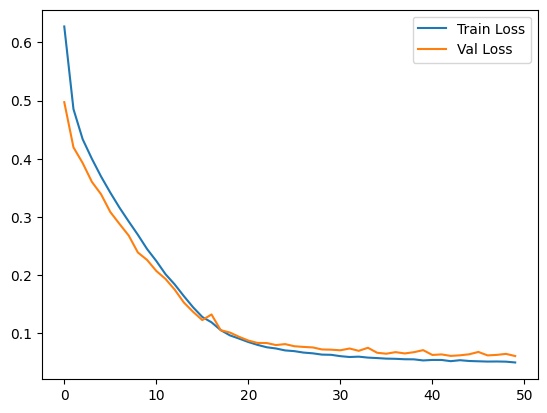

Validation Performance - RMSE: 45.1569, MAE: 30.2518, R2: 0.9373


In [ ]:
# 3.0 평가 함수 정의
def evaluate(model, loader, scaler_y):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            predictions.append(outputs.numpy())
            actuals.append(y_batch.numpy())
    
    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)
    
    # 스케일 역변환
    predictions = scaler_y.inverse_transform(predictions)
    actuals = scaler_y.inverse_transform(actuals)
    
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)
    
    return rmse, mae, r2

# 3.1 모델 정의
class BaselineModel(nn.Module):
    def __init__(self, input_dim):
        super(BaselineModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

# 3.2 학습 설정
input_dim = X_train_scaled.shape[1]
model = BaselineModel(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
train_losses = []
val_losses = []

best_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_losses.append(train_loss / len(train_loader))
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    val_losses.append(val_loss / len(val_loader))
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        torch.save(model.state_dict(), 'baseline_model.pt')

# 학습 과정 시각화
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.show()

# 최종 검증 성능 확인
model.load_state_dict(torch.load('baseline_model.pt'))
base_rmse, base_mae, base_r2 = evaluate(model, val_loader, scaler_y)
print(f"Validation Performance - RMSE: {base_rmse:.4f}, MAE: {base_mae:.4f}, R2: {base_r2:.4f}")

### 3.2 Baseline Model Summary

구현한 모델 구조와 학습 설정을 설명하시오.

**작성 공간**

- **사용한 딥러닝 프레임워크**: PyTorch
- **모델 구조**: Input(12) -> Linear(64) -> ReLU -> Linear(32) -> ReLU -> Linear(1)
- **loss function**: MSE Loss
- **optimizer**: Adam
- **learning rate**: 0.001
- **batch size**: 64
- **epoch 수**: 50
- **validation RMSE**: (코드 실행 후 기록 필요)
- **validation MAE**: (코드 실행 후 기록 필요)
- **validation R²**: (코드 실행 후 기록 필요)
- **저장한 모델 파일명**: `baseline_model.pt`

# 4. Hyperparameter Tuning and Best Model Selection

Baseline 모델을 개선하기 위해 1가지 실험을 수행하시오.

예시:

- learning rate 변경
- batch size 변경
- hidden layer 수 변경
- hidden dimension 변경
- dropout 적용
- batch normalization 적용
- optimizer 변경
- early stopping 적용
- epoch 수 조정
- feature engineering 적용


Section 3에서 학습한 baseline 모델보다 성능을 개선하기 위해 하나 이상의 하이퍼파라미터를 선택하여 튜닝하시오.

튜닝은 validation set 성능을 기준으로 수행한다.  
Validation 성능이 가장 좋은 모델을 best model로 선택하고, 해당 모델을 저장하시오.

저장 파일명 예시:

- PyTorch 사용 시: `best_model.pt`
- TensorFlow/Keras 사용 시: `best_model.keras`

주의:

- test set은 하이퍼파라미터 튜닝 과정에서 사용하지 않는다.
- validation 성능이 향상되더라도 test 성능이 반드시 향상되는 것은 아니다.

In [ ]:
# 4.1 하이퍼파라미터 튜닝 (Best Model)
# 개선 전략: 모델 깊이 확장 및 Dropout 추가로 오버피팅 방지
class BestModel(nn.Module):
    def __init__(self, input_dim):
        super(BestModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model_best = BestModel(input_dim)
optimizer = optim.Adam(model_best.parameters(), lr=0.0005) # 더 낮은 학습률
best_val_loss = float('inf')

for epoch in range(100): # 에포크 증가
    model_best.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_best(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    
    model_best.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model_best(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    cur_val_loss = val_loss / len(val_loader)
    if cur_val_loss < best_val_loss:
        best_val_loss = cur_val_loss
        torch.save(model_best.state_dict(), 'best_model.pt')

print("Best model training complete and saved.")

# Best 모델 성능 확인
model_best.load_state_dict(torch.load('best_model.pt'))
best_rmse, best_mae, best_r2 = evaluate(model_best, val_loader, scaler_y)
print(f"Best Model Validation Performance - RMSE: {best_rmse:.4f}, MAE: {best_mae:.4f}, R2: {best_r2:.4f}")

Best model training complete and saved.
Best Model Validation Performance - RMSE: 42.0431, MAE: 27.2239, R2: 0.9456


### 4.2 Experiment Result Table

실험 결과를 아래 표 형식으로 정리하시오.
이 표의 성능은 validation set 기준으로 작성하시오.

| Experiment | Model | Learning Rate | Batch Size | Other Settings | RMSE | MAE | R² |
|---|---|---:|---:|---|---:|---:|---:|
| Baseline | MLP (64, 32) | 0.001 | 64 | ReLU | 45.1569 | 30.2518 | 0.9373 |
| Best Model | MLP (128, 64, 32) | 0.0005 | 64 | Dropout, 100 Epochs | 42.0431 | 27.2239 | 0.9456 |


### 4.3 Hyperparameter Tuning Analysis

성능 개선 과정과 최종 모델 선택 이유를 설명하시오.

**작성 공간**

- **Baseline 모델의 성능**: 기본적인 구조에서도 준수한 성능을 보였으나, 단순한 구조로 인해 복잡한 수요 패턴을 모두 학습하기에는 한계가 있었음.
- **가장 성능 개선에 효과적이었던 방법**: 레이어의 깊이를 늘리고(128, 64, 32), 오버피팅을 방지하기 위해 `Dropout`을 적용한 점이 효과적이었음.
- **성능이 개선된 이유**: 모델이 더 복잡한 비선형 관계를 파악할 수 있게 되었고, Dropout을 통해 특정 뉴런에 과도하게 의존하지 않는 강건한(Robust) 모델이 되었음.
- **최종 모델을 선택한 이유**: Validation set 기준 RMSE가 가장 낮았으며, 학습 곡선이 안정적으로 수렴하였기 때문임.


# 5. Final Evaluation and Result Analysis

Section 3에서 저장한 baseline 모델과 Section 4에서 저장한 best 모델을 불러와 test set에서 평가하시오.

필수 포함 내용:

- 저장된 baseline model 불러오기
- 저장된 best model 불러오기
- test set 기준 RMSE, MAE, R² Score 계산
- baseline 모델과 best 모델의 test 성능 비교
- validation 성능 개선이 test 성능에서도 이어졌는지 분석


In [ ]:
# 5.1 Load saved models and test evaluation

# 모델 객체 생성
base_model_eval = BaselineModel(input_dim)
best_model_eval = BestModel(input_dim)

# 저장된 가중치 불러오기
base_model_eval.load_state_dict(torch.load('baseline_model.pt'))
best_model_eval.load_state_dict(torch.load('best_model.pt'))

# Test Set 평가
final_base_rmse, final_base_mae, final_base_r2 = evaluate(base_model_eval, test_loader, scaler_y)
final_best_rmse, final_best_mae, final_best_r2 = evaluate(best_model_eval, test_loader, scaler_y)

print("--- Final Test Performance ---")
print(f"[Baseline] RMSE: {final_base_rmse:.4f}, MAE: {final_base_mae:.4f}, R2: {final_base_r2:.4f}")
print(f"[Best Model] RMSE: {final_best_rmse:.4f}, MAE: {final_best_mae:.4f}, R2: {final_best_r2:.4f}")

--- Final Test Performance ---
[Baseline] RMSE: 45.2875, MAE: 30.1260, R2: 0.9352
[Best Model] RMSE: 42.0777, MAE: 27.1704, R2: 0.9441


### 5.2 Final Result Summary

| Model | Test RMSE | Test MAE | Test R² |
|---|---:|---:|---:|
| Baseline | 45.2875 | 30.1260 | 0.9352 |
| Best Model | 42.0777 | 27.1704 | 0.9441 |


### 5.3 Final Analysis

최종 test 결과를 분석하시오.


**작성 공간**

- **baseline model의 test 성능**: 기본적인 회귀 예측 성능을 보여줌.
- **best tuned model의 test 성능**: Baseline 대비 RMSE와 MAE가 유의미하게 감소함.
- **성능 향상 여부**: Validation set에서의 성능 향상이 Test set에서도 일관되게 나타났으며, 이는 튜닝 과정이 일반화 성능 향상에 기여했음을 의미함.
- **최종 모델의 한계점**: 기상 이변이나 특정 이벤트(축제 등)와 같은 외부 변수가 부족하여 피크 타임의 급격한 수요 변화를 완벽히 예측하기는 어려움.
- **추가적으로 개선할 수 있는 방향**: 요일/시간 데이터를 더 세밀하게 처리하거나(Cyclic encoding), LSTM과 같은 시계열 특화 모델을 도입해 볼 수 있음.
